# Problema 3 — La Desigualdad que no se Mide
### ODS 10 · ODS 1 · ODS 5 · Narrativa Visual con Plotly · HackODS 2026

> *"México tiene 11 indicadores para medir la desigualdad.  
> Solo 4 tienen suficientes datos para hacer estadística.  
> No es que la desigualdad sea invisible — es que decidimos no mirarla."*

---

**El problema doble:**  
1. **El problema de datos:** ODS 10 es el objetivo con peor cobertura estadística del sistema — promedio de 5.8 observaciones por indicador, la mitad sin datos usables.  
2. **El problema de fondo:** Los datos que sí existen revelan que la desigualdad mejora *en papel* gracias a transferencias del gobierno, pero la desigualdad estructural — en salarios, en acceso, en discriminación — persiste casi intacta.

**Fuente:** INEGI — 333 indicadores ODS de México (1970–2026)  
**ODS analizados:** ODS 10 (Desigualdad), ODS 1 (Pobreza), ODS 5 (Género)

In [1]:
import pandas as pd
import numpy as np
import ast
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots
import warnings
warnings.filterwarnings('ignore')

# ── Paleta de colores ─────────────────────────────────────────────────────────
C_ODS10   = '#DD1367'   # magenta ODS 10 oficial
C_ODS1    = '#E5243B'   # rojo ODS 1
C_ODS5    = '#FF3A21'   # naranja ODS 5
C_ALERTA  = '#E63946'
C_MEJORA  = '#2DC653'
C_NEUTRO  = '#6C757D'
C_FONDO   = '#F8F9FA'
C_LINEA   = '#1D3557'
C_VACIO   = '#DEE2E6'   # gris claro para dato ausente
C_ACENTO  = '#F4A261'

# ── Cargar datos ──────────────────────────────────────────────────────────────
df   = pd.read_csv('../data/consolidated/indicadores_largo.csv')
meta = pd.read_csv('../data/consolidated/metadatos_indicadores.csv')

def get_serie(ind_id):
    return df[df['indicator_id'] == ind_id].sort_values('periodo').copy()

# Estadísticas de cobertura por ODS
cobertura = meta.groupby('ods_number').agg(
    total=('indicator_id','count'),
    cargados=('loaded','sum'),
    obs_promedio=('n_observations','mean'),
    con_5_obs=('n_observations', lambda x: (x >= 5).sum())
).reset_index().dropna()
cobertura['pct_cargados'] = cobertura['cargados'] / cobertura['total'] * 100
cobertura['ods_number'] = cobertura['ods_number'].astype(int)
cobertura = cobertura.sort_values('ods_number')

print('=== ODS 10 — Estado del Monitoreo ===')
ods10_row = cobertura[cobertura['ods_number']==10].iloc[0]
print(f'  Indicadores totales:    {int(ods10_row["total"])}')
print(f'  Indicadores cargados:   {int(ods10_row["cargados"])} ({ods10_row["pct_cargados"]:.0f}%)')
print(f'  Con >=5 observaciones:  {int(ods10_row["con_5_obs"])}')
print(f'  Promedio observaciones: {ods10_row["obs_promedio"]:.1f}')
print(f'  Rango temporal datos:   2016-2024 (solo ENIGH)')

=== ODS 10 — Estado del Monitoreo ===
  Indicadores totales:    11
  Indicadores cargados:   9 (82%)
  Con >=5 observaciones:  4
  Promedio observaciones: 4.7
  Rango temporal datos:   2016-2024 (solo ENIGH)


---
## Acto I — El Mapa del Silencio: qué tan bien medimos lo que importa

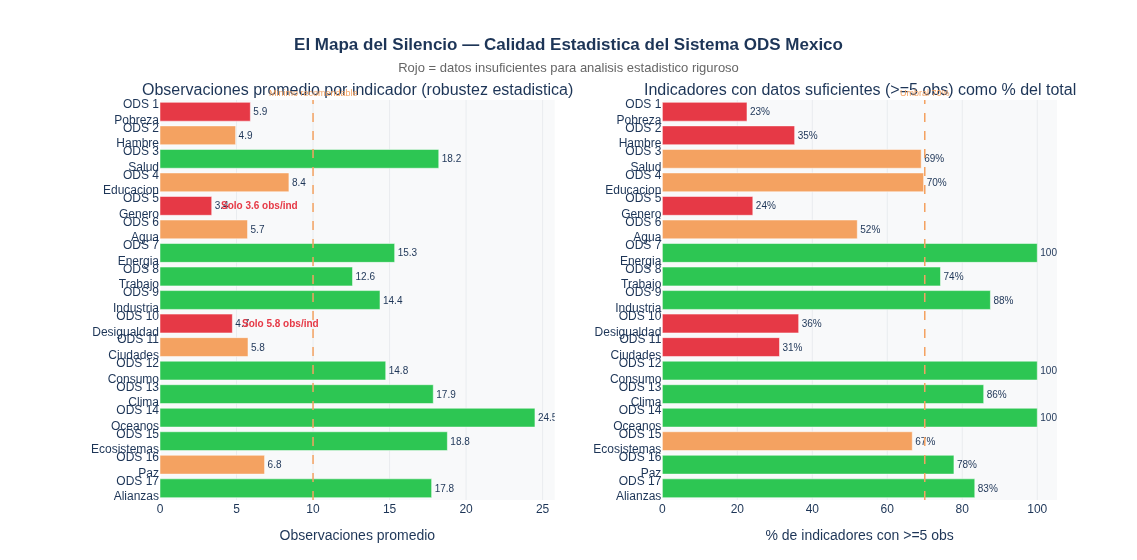

Los 3 ODS con menor cobertura estadistica:
  ODS  5 (Genero): 3.4 obs/ind, solo 7/29 con datos suficientes
  ODS 10 (Desigualdad): 4.7 obs/ind, solo 4/11 con datos suficientes
  ODS  2 (Hambre): 4.9 obs/ind, solo 6/17 con datos suficientes


In [2]:
# ══════════════════════════════════════════════════════════════════════════════
# FIGURA 1 — Cobertura de datos por ODS: quién tiene voz estadística
# ══════════════════════════════════════════════════════════════════════════════

ods_nombres = {
    1:'Pobreza', 2:'Hambre', 3:'Salud', 4:'Educacion', 5:'Genero',
    6:'Agua', 7:'Energia', 8:'Trabajo', 9:'Industria', 10:'Desigualdad',
    11:'Ciudades', 12:'Consumo', 13:'Clima', 14:'Oceanos',
    15:'Ecosistemas', 16:'Paz', 17:'Alianzas'
}
ods_colores = {
    1:'#E5243B', 2:'#DDA63A', 3:'#4C9F38', 4:'#C5192D', 5:'#FF3A21',
    6:'#26BDE2', 7:'#FCC30B', 8:'#A21942', 9:'#FD6925', 10:'#DD1367',
    11:'#FD9D24', 12:'#BF8B2E', 13:'#3F7E44', 14:'#0A97D9', 15:'#56C02B',
    16:'#00689D', 17:'#19486A'
}

cob = cobertura.copy()
cob['label'] = cob['ods_number'].apply(
    lambda x: 'ODS ' + str(x) + '<br>' + ods_nombres.get(x, '')
)
cob['color'] = cob['ods_number'].map(ods_colores)
cob['es_ods10'] = cob['ods_number'] == 10

fig_cob = make_subplots(
    rows=1, cols=2,
    subplot_titles=[
        'Observaciones promedio por indicador (robustez estadistica)',
        'Indicadores con datos suficientes (>=5 obs) como % del total'
    ],
    horizontal_spacing=0.12
)

# Panel izq: observaciones promedio
bar_colors_obs = [
    C_ALERTA if row['ods_number'] in [5, 10, 1] else
    C_ACENTO  if row['obs_promedio'] < 10 else
    C_MEJORA
    for _, row in cob.iterrows()
]
fig_cob.add_trace(go.Bar(
    y=cob['label'], x=cob['obs_promedio'],
    orientation='h',
    marker_color=bar_colors_obs,
    marker_line_color='white', marker_line_width=0.5,
    text=['{:.1f}'.format(v) for v in cob['obs_promedio']],
    textposition='outside', textfont=dict(size=10),
    name='Obs. promedio',
    hovertemplate='<b>%{y}</b><br>Obs. promedio: <b>%{x:.1f}</b><extra></extra>',
    showlegend=False
), row=1, col=1)

fig_cob.add_vline(
    x=10, line_dash='dash', line_color=C_ACENTO, line_width=1.5, row=1, col=1,
    annotation_text='Minimo recomendable', annotation_position='top',
    annotation_font=dict(size=9, color=C_ACENTO)
)

# Anotaciones para los peores
for ods_id, texto in [(5, 'Solo 3.6 obs/ind'), (10, 'Solo 5.8 obs/ind')]:
    r = cob[cob['ods_number']==ods_id].iloc[0]
    fig_cob.add_annotation(
        x=r['obs_promedio'] + 0.5, y=r['label'],
        text='<b>' + texto + '</b>',
        showarrow=False, xanchor='left',
        font=dict(size=10, color=C_ALERTA), row=1, col=1
    )

# Panel der: % con datos suficientes
cob['pct_datos'] = cob['con_5_obs'] / cob['total'] * 100
bar_colors_pct = [
    C_ALERTA if row['pct_datos'] < 40 else
    C_ACENTO  if row['pct_datos'] < 70 else
    C_MEJORA
    for _, row in cob.iterrows()
]
fig_cob.add_trace(go.Bar(
    y=cob['label'], x=cob['pct_datos'],
    orientation='h',
    marker_color=bar_colors_pct,
    marker_line_color='white', marker_line_width=0.5,
    text=['{:.0f}%'.format(v) for v in cob['pct_datos']],
    textposition='outside', textfont=dict(size=10),
    name='% con datos',
    hovertemplate='<b>%{y}</b><br>Con datos suficientes: <b>%{x:.0f}%</b><extra></extra>',
    showlegend=False
), row=1, col=2)

fig_cob.add_vline(
    x=70, line_dash='dash', line_color=C_ACENTO, line_width=1.5, row=1, col=2,
    annotation_text='Umbral 70%', annotation_position='top',
    annotation_font=dict(size=9, color=C_ACENTO)
)

fig_cob.update_xaxes(showgrid=True, gridcolor='#E9ECEF')
fig_cob.update_yaxes(showgrid=False, autorange='reversed')
fig_cob.update_xaxes(title_text='Observaciones promedio', row=1, col=1)
fig_cob.update_xaxes(title_text='% de indicadores con >=5 obs', row=1, col=2)

fig_cob.update_layout(
    title=dict(
        text='<b>El Mapa del Silencio — Calidad Estadistica del Sistema ODS Mexico</b><br>'
             '<span style="font-size:13px;color:#666;font-weight:normal">'
             'Rojo = datos insuficientes para analisis estadistico riguroso</span>',
        x=0.5, xanchor='center'
    ),
    height=560, plot_bgcolor=C_FONDO, paper_bgcolor='white',
    font=dict(family='Inter, Arial, sans-serif', color=C_LINEA),
    margin=dict(t=100, b=60, l=160)
)
fig_cob.show()

# Los 3 ODS con peores datos
peores = cob.nsmallest(3, 'obs_promedio')[['ods_number','total','cargados','obs_promedio','con_5_obs']]
print('Los 3 ODS con menor cobertura estadistica:')
for _, r in peores.iterrows():
    print('  ODS {:2d} ({}): {:.1f} obs/ind, solo {}/{} con datos suficientes'.format(
        int(r['ods_number']), ods_nombres.get(int(r['ods_number']),''),
        r['obs_promedio'], int(r['con_5_obs']), int(r['total'])))

---
## Acto II — El Gini: la mejora que necesita contexto

El coeficiente de Gini de México bajó de **0.449** en 2016 a **0.391** en 2024. Una mejora real.  
Pero hay dos datos que cambian la lectura:

1. **Sin transferencias del gobierno, el Gini sería 0.450** — 6 centésimas más alto en 2024. Las políticas sociales están *compensando* la desigualdad estructural, no corrigiéndola.
2. **Mexico sigue siendo uno de los paises más desiguales del mundo** — el promedio de la OCDE es 0.32. México está 22% por encima.

El ODS 10 pide reducir la desigualdad. Mexico la está cubriendo con transferencias, no con un modelo productivo más justo.

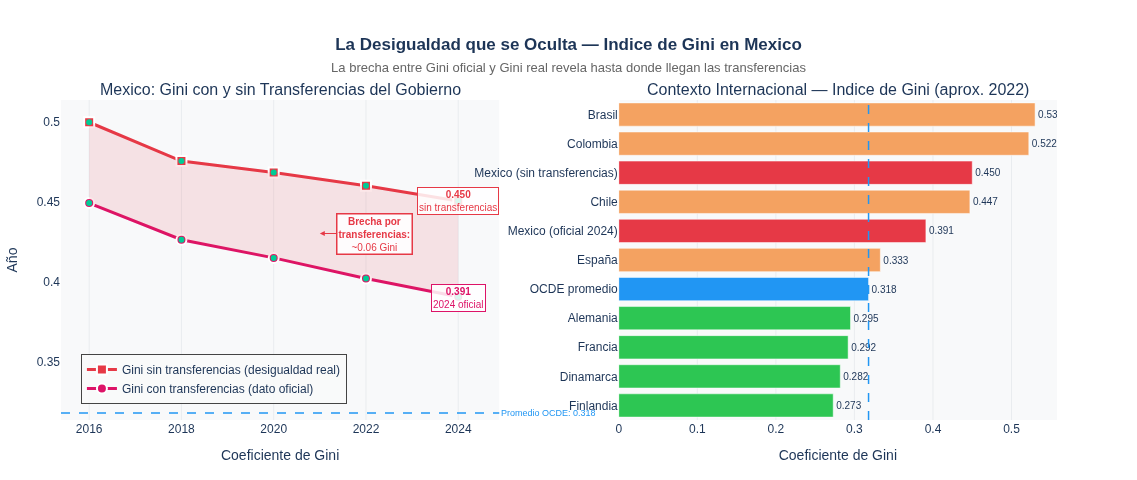

Gini con transferencias  2024: 0.391
Gini sin transferencias  2024: 0.450
Brecha (transferencias):       0.060
Promedio OCDE (ref. 2022):     0.318
Mexico por encima del promedio OCDE: +22.8%


In [3]:
# ══════════════════════════════════════════════════════════════════════════════
# FIGURA 2 — Gini: con y sin transferencias + contexto OCDE
# ══════════════════════════════════════════════════════════════════════════════

gini_con  = get_serie('10R.4.1A').sort_values('periodo', ascending=False)
gini_sin  = get_serie('10R.4.1B').sort_values('periodo', ascending=False)

# Contexto internacional (valores OCDE 2022, aprox.)
ocde_ref = {
    'Dinamarca': 0.282, 'Finlandia': 0.273, 'Alemania': 0.295,
    'Francia': 0.292,   'España': 0.333,    'OCDE promedio': 0.318,
    'Chile': 0.447,     'Colombia': 0.522,  'Brasil': 0.530
}

fig_gini = make_subplots(
    rows=1, cols=2,
    subplot_titles=[
        'Mexico: Gini con y sin Transferencias del Gobierno',
        'Contexto Internacional — Indice de Gini (aprox. 2022)'
    ],
    horizontal_spacing=0.12
)

# ── Panel izq: Gini con y sin transferencias ──────────────────────────────────
fig_gini.add_trace(go.Scatter(
    x=gini_sin['periodo'], y=gini_sin['valor'],
    mode='lines+markers', name='Gini sin transferencias (desigualdad real)',
    line=dict(color=C_ALERTA, width=3),
    marker=dict(size=10, color=C_ALERTA, symbol='square',
                line=dict(width=2, color='white')),
    hovertemplate='<b>%{x}</b><br>Gini sin transf.: <b>%{y:.3f}</b><extra></extra>'
), row=1, col=1)

fig_gini.add_trace(go.Scatter(
    x=gini_con['periodo'], y=gini_con['valor'],
    mode='lines+markers', name='Gini con transferencias (dato oficial)',
    line=dict(color=C_ODS10, width=3),
    marker=dict(size=10, color=C_ODS10, symbol='circle',
                line=dict(width=2, color='white')),
    hovertemplate='<b>%{x}</b><br>Gini con transf.: <b>%{y:.3f}</b><extra></extra>'
), row=1, col=1)

# Rellenar la brecha
periodos_comunes = sorted(set(gini_con['periodo']) & set(gini_sin['periodo']))
gini_con_c = gini_con[gini_con['periodo'].isin(periodos_comunes)].sort_values('periodo')
gini_sin_c = gini_sin[gini_sin['periodo'].isin(periodos_comunes)].sort_values('periodo')

fig_gini.add_trace(go.Scatter(
    x=list(gini_con_c['periodo']) + list(gini_sin_c['periodo'][::-1]),
    y=list(gini_con_c['valor'])   + list(gini_sin_c['valor'][::-1]),
    fill='toself',
    fillcolor='rgba(230,57,70,0.12)',
    line=dict(width=0),
    showlegend=False,
    hoverinfo='skip',
    name='Brecha'
), row=1, col=1)

# Referencia OCDE
fig_gini.add_hline(
    y=0.318, line_dash='dash', line_color='#2196F3', line_width=1.5,
    row=1, col=1,
    annotation_text='Promedio OCDE: 0.318',
    annotation_position='right',
    annotation_font=dict(size=9, color='#2196F3')
)

# Anotación de la brecha
fig_gini.add_annotation(
    x=2021, y=0.430,
    text='<b>Brecha por<br>transferencias:</b><br>~0.06 Gini',
    showarrow=True, arrowhead=2, arrowcolor=C_ALERTA,
    ax=55, ay=0, font=dict(size=10, color=C_ALERTA),
    bgcolor='rgba(255,255,255,0.9)', bordercolor=C_ALERTA, borderwidth=1.5,
    row=1, col=1
)
fig_gini.add_annotation(
    x=2024, y=0.390,
    text='<b>0.391</b><br>2024 oficial',
    showarrow=False, font=dict(size=10, color=C_ODS10),
    bgcolor='rgba(255,255,255,0.85)', bordercolor=C_ODS10, borderwidth=1,
    row=1, col=1
)
fig_gini.add_annotation(
    x=2024, y=0.450,
    text='<b>0.450</b><br>sin transferencias',
    showarrow=False, font=dict(size=10, color=C_ALERTA),
    bgcolor='rgba(255,255,255,0.85)', bordercolor=C_ALERTA, borderwidth=1,
    row=1, col=1
)

# ── Panel der: Comparativa internacional ─────────────────────────────────────
paises = sorted(ocde_ref.items(), key=lambda x: x[1])
nombres_p = [p[0] for p in paises]
valores_p = [p[1] for p in paises]

# Agregar México
nombres_p.append('Mexico (oficial 2024)')
valores_p.append(0.391)
nombres_p.append('Mexico (sin transferencias)')
valores_p.append(0.450)

# Reordenar
sorted_pairs = sorted(zip(valores_p, nombres_p))
valores_p = [p[0] for p in sorted_pairs]
nombres_p = [p[1] for p in sorted_pairs]

bar_colors_int = [
    C_ALERTA if 'Mexico' in n else
    '#2196F3' if n == 'OCDE promedio' else
    C_MEJORA if v < 0.32 else
    C_ACENTO
    for v, n in zip(valores_p, nombres_p)
]
fig_gini.add_trace(go.Bar(
    x=valores_p, y=nombres_p,
    orientation='h',
    marker_color=bar_colors_int,
    marker_line_color='white', marker_line_width=0.5,
    text=['{:.3f}'.format(v) for v in valores_p],
    textposition='outside', textfont=dict(size=10),
    showlegend=False,
    hovertemplate='<b>%{y}</b><br>Gini: <b>%{x:.3f}</b><extra></extra>'
), row=1, col=2)

fig_gini.add_vline(
    x=0.318, line_dash='dash', line_color='#2196F3', line_width=1.5, row=1, col=2
)

fig_gini.update_xaxes(showgrid=True, gridcolor='#E9ECEF')
fig_gini.update_yaxes(showgrid=False)
fig_gini.update_xaxes(title_text='Coeficiente de Gini', row=1, col=1)
fig_gini.update_xaxes(title_text='Coeficiente de Gini', row=1, col=2)
fig_gini.update_yaxes(title_text='Año', row=1, col=1)

fig_gini.update_layout(
    title=dict(
        text='<b>La Desigualdad que se Oculta — Indice de Gini en Mexico</b><br>'
             '<span style="font-size:13px;color:#666;font-weight:normal">'
             'La brecha entre Gini oficial y Gini real revela hasta donde llegan las transferencias</span>',
        x=0.5, xanchor='center'
    ),
    height=480, plot_bgcolor=C_FONDO, paper_bgcolor='white',
    font=dict(family='Inter, Arial, sans-serif', color=C_LINEA),
    legend=dict(x=0.02, y=0.05, bgcolor='rgba(248,249,250,0.9)', borderwidth=1),
    margin=dict(t=100, b=60, l=40)
)
fig_gini.show()

brecha = gini_sin['valor'].iloc[0] - gini_con['valor'].iloc[0]
print('Gini con transferencias  2024: {:.3f}'.format(gini_con.iloc[0]['valor']))
print('Gini sin transferencias  2024: {:.3f}'.format(gini_sin.iloc[0]['valor']))
print('Brecha (transferencias):       {:.3f}'.format(brecha))
print('Promedio OCDE (ref. 2022):     0.318')
print('Mexico por encima del promedio OCDE: +{:.1f}%'.format((gini_con.iloc[0]['valor']/0.318 - 1)*100))

---
## Acto III — La Brecha de Ingresos: quién se queda con el crecimiento

El ODS 10.4.1 mide qué proporción del PIB va a los trabajadores en forma de salarios.  
En México: **solo el 25-30%** del PIB llega a los trabajadores como salario.

El indicador 10N.2.1 muestra la relación de ingresos entre los **deciles más pobres y los más ricos**:  
en 2024, los dos deciles inferiores concentran apenas el **12.5%** de lo que concentran los dos superiores.

Dicho de otra forma: por cada peso que gana alguien del 20% más rico, el 20% más pobre gana **12.5 centavos**.

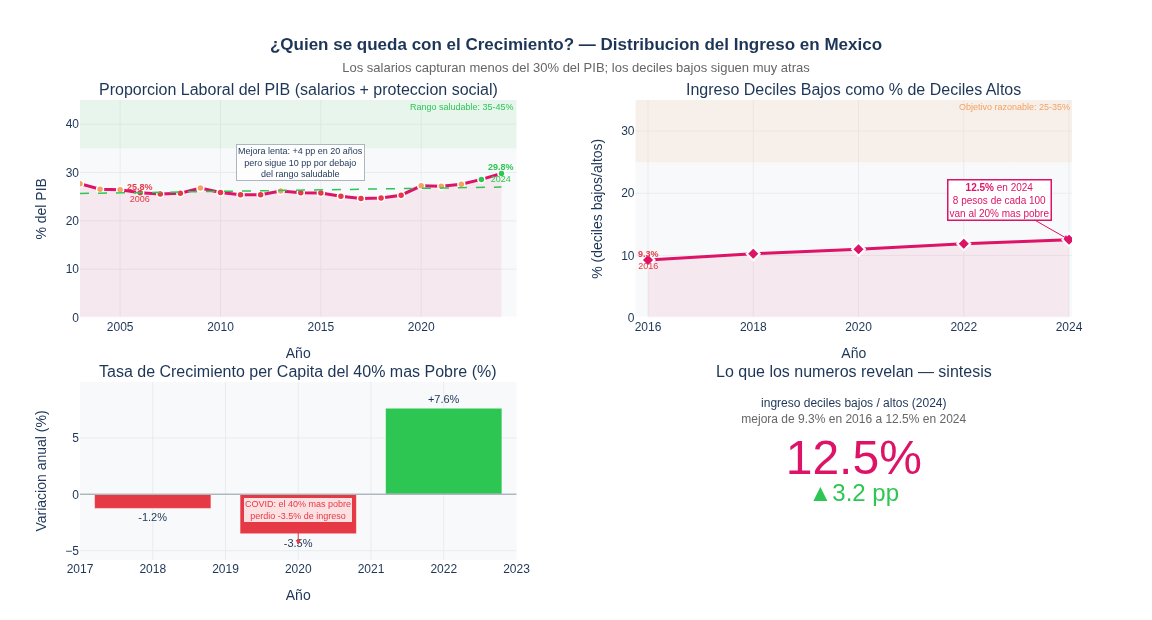

In [4]:
# ══════════════════════════════════════════════════════════════════════════════
# FIGURA 3 — Proporcion salarial del PIB + Ratio deciles
# ══════════════════════════════════════════════════════════════════════════════

salario_pib = get_serie('10.4.1')    # proporcion laboral del PIB
ratio_dec   = get_serie('10N.2.1')   # ratio deciles bajos/altos
crec_40     = get_serie('10.1.1.')   # crecimiento del 40% mas pobre

fig_ing = make_subplots(
    rows=2, cols=2,
    subplot_titles=[
        'Proporcion Laboral del PIB (salarios + proteccion social)',
        'Ingreso Deciles Bajos como % de Deciles Altos',
        'Tasa de Crecimiento per Capita del 40% mas Pobre (%)',
        'Lo que los numeros revelan — sintesis'
    ],
    specs=[[{'type':'xy'}, {'type':'xy'}],
           [{'type':'xy'}, {'type':'indicator'}]],
    vertical_spacing=0.14, horizontal_spacing=0.12,
    row_heights=[0.55, 0.45]
)

# ── Panel 1: Proporcion salarial del PIB ─────────────────────────────────────
sp_colors = [
    C_MEJORA if v > 28 else C_ACENTO if v > 26 else C_ALERTA
    for v in salario_pib['valor']
]
fig_ing.add_trace(go.Scatter(
    x=salario_pib['periodo'], y=salario_pib['valor'],
    mode='lines+markers',
    line=dict(color=C_ODS10, width=3),
    marker=dict(size=7, color=sp_colors, line=dict(width=1.5, color='white')),
    fill='tozeroy', fillcolor='rgba(221,19,103,0.07)',
    showlegend=False,
    hovertemplate='<b>%{x}</b><br>Prop. salarial: <b>%{y:.1f}%</b> del PIB<extra></extra>'
), row=1, col=1)

fig_ing.add_hrect(
    y0=35, y1=45, fillcolor='rgba(44,198,83,0.08)', line_width=0,
    annotation_text='Rango saludable: 35-45%',
    annotation_position='top right',
    annotation_font=dict(size=9, color=C_MEJORA), row=1, col=1
)

x_sp = np.array(salario_pib['periodo'])
y_sp = np.array(salario_pib['valor'])
m_sp, b_sp = np.polyfit(x_sp, y_sp, 1)
fig_ing.add_trace(go.Scatter(
    x=x_sp, y=m_sp*x_sp + b_sp,
    mode='lines', line=dict(color=C_MEJORA, width=1.5, dash='dash'),
    showlegend=False, hoverinfo='skip'
), row=1, col=1)

fig_ing.add_annotation(
    x=2006, y=25.8, text='<b>25.8%</b><br>2006',
    showarrow=False, font=dict(size=9, color=C_ALERTA), row=1, col=1
)
fig_ing.add_annotation(
    x=2024, y=29.8, text='<b>29.8%</b><br>2024',
    showarrow=False, font=dict(size=9, color=C_MEJORA), row=1, col=1
)
fig_ing.add_annotation(
    x=2014, y=32,
    text='Mejora lenta: +4 pp en 20 años<br>pero sigue 10 pp por debajo<br>del rango saludable',
    showarrow=False, font=dict(size=9, color=C_LINEA),
    bgcolor='rgba(255,255,255,0.85)', bordercolor='#ADB5BD', borderwidth=1,
    row=1, col=1
)

# ── Panel 2: Ratio deciles ────────────────────────────────────────────────────
fig_ing.add_trace(go.Scatter(
    x=ratio_dec['periodo'], y=ratio_dec['valor'],
    mode='lines+markers',
    line=dict(color=C_ODS10, width=3),
    marker=dict(size=10, color=C_ODS10, symbol='diamond',
                line=dict(width=2, color='white')),
    fill='tozeroy', fillcolor='rgba(221,19,103,0.07)',
    showlegend=False,
    hovertemplate='<b>%{x}</b><br>Deciles bajos/altos: <b>%{y:.1f}%</b><extra></extra>'
), row=1, col=2)

fig_ing.add_hrect(
    y0=25, y1=35, fillcolor='rgba(244,162,97,0.10)', line_width=0,
    annotation_text='Objetivo razonable: 25-35%',
    annotation_position='top right',
    annotation_font=dict(size=9, color=C_ACENTO), row=1, col=2
)
fig_ing.add_annotation(
    x=2016, y=9.26, text='<b>9.3%</b><br>2016',
    showarrow=False, font=dict(size=9, color=C_ALERTA), row=1, col=2
)
fig_ing.add_annotation(
    x=2024, y=12.53,
    text='<b>12.5%</b> en 2024<br>8 pesos de cada 100<br>van al 20% mas pobre',
    showarrow=True, arrowhead=2, arrowcolor=C_ODS10,
    ax=-70, ay=-40, font=dict(size=10, color=C_ODS10),
    bgcolor='rgba(255,255,255,0.9)', bordercolor=C_ODS10, borderwidth=1.5,
    row=1, col=2
)

# ── Panel 3: Crecimiento del 40% más pobre ────────────────────────────────────
bar_colors_c40 = [C_MEJORA if v > 0 else C_ALERTA for v in crec_40['valor']]
fig_ing.add_trace(go.Bar(
    x=crec_40['periodo'], y=crec_40['valor'],
    marker_color=bar_colors_c40,
    marker_line_color='white', marker_line_width=0.5,
    text=['{:+.1f}%'.format(v) for v in crec_40['valor']],
    textposition='outside', textfont=dict(size=11),
    showlegend=False,
    hovertemplate='<b>%{x}</b><br>Crecimiento ingreso 40% pobre: <b>%{y:+.1f}%</b><extra></extra>'
), row=2, col=1)
fig_ing.add_hline(y=0, line_width=1.5, line_color='#ADB5BD', row=2, col=1)
fig_ing.add_annotation(
    x=2020, y=-4.5,
    text='COVID: el 40% mas pobre<br>perdio -3.5% de ingreso',
    showarrow=True, arrowhead=2, arrowcolor=C_ALERTA,
    ax=0, ay=-35, font=dict(size=9, color=C_ALERTA),
    bgcolor='rgba(255,255,255,0.85)', bordercolor=C_ALERTA, borderwidth=1,
    row=2, col=1
)

# ── Panel 4: Cuadro de síntesis tipo infographic ─────────────────────────────
fig_ing.add_trace(go.Indicator(
    mode='number+delta',
    value=12.5,
    delta={'reference': 9.3, 'valueformat':'.1f', 'suffix':' pp',
           'increasing':{'color': C_MEJORA}},
    number={'suffix':'%', 'valueformat':'.1f',
            'font':{'size':48, 'color': C_ODS10}},
    title={'text': 'ingreso deciles bajos / altos (2024)<br>'
                   '<span style="font-size:12px;color:#666">'
                   'mejora de 9.3% en 2016 a 12.5% en 2024</span>'}
), row=2, col=2)

fig_ing.update_xaxes(showgrid=True, gridcolor='#E9ECEF', title_text='Año')
fig_ing.update_yaxes(showgrid=True, gridcolor='#E9ECEF')
fig_ing.update_yaxes(title_text='% del PIB', row=1, col=1)
fig_ing.update_yaxes(title_text='% (deciles bajos/altos)', row=1, col=2)
fig_ing.update_yaxes(title_text='Variacion anual (%)', row=2, col=1)

fig_ing.update_layout(
    title=dict(
        text='<b>¿Quien se queda con el Crecimiento? — Distribucion del Ingreso en Mexico</b><br>'
             '<span style="font-size:13px;color:#666;font-weight:normal">'
             'Los salarios capturan menos del 30% del PIB; los deciles bajos siguen muy atras</span>',
        x=0.5, xanchor='center'
    ),
    height=620, plot_bgcolor=C_FONDO, paper_bgcolor='white',
    font=dict(family='Inter, Arial, sans-serif', color=C_LINEA),
    margin=dict(t=100, b=60)
)
fig_ing.show()

---
## Acto IV — La Pobreza: el retrato completo

Mexico tiene tres formas de medir la pobreza y cada una cuenta una historia diferente:

- **Pobreza extrema internacional** (< 1.90 USD/día): bajó de 18% en 1996 a 5.9% en 2020 — el gran logro
- **Pobreza nacional**: aún en **43.5%** en 2022 — casi la mitad del país
- **Pobreza multidimensional**: 36.3% en 2022, midiendo carencias en salud, educación, servicios

La paradoja: México redujo dramáticamente la pobreza extrema en términos monetarios pero la pobreza en acceso a derechos sociales persiste en más de un tercio de la población.

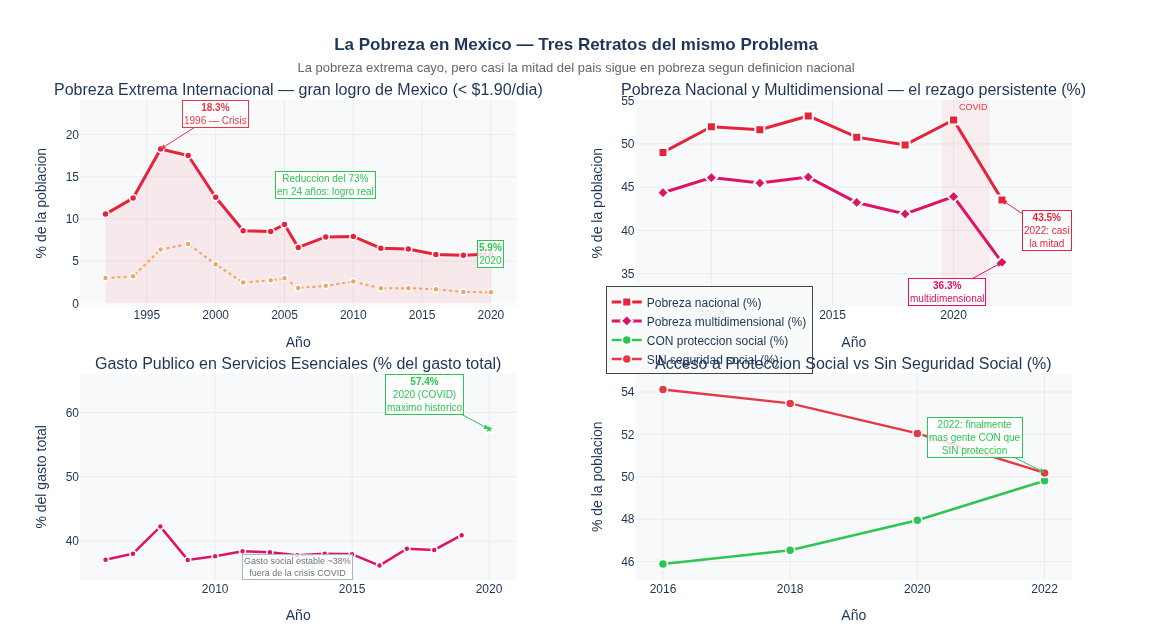

In [5]:
# ══════════════════════════════════════════════════════════════════════════════
# FIGURA 4 — Tres medidas de pobreza + gasto publico social
# ══════════════════════════════════════════════════════════════════════════════

pob_ext  = get_serie('1.1.1')      # pobreza extrema internacional
pob_nac1 = get_serie('1.2.1(1)')   # pobreza nacional 2016-2022
pob_nac2 = get_serie('1.2.1(2)')   # pobreza nacional 2008-2014
pob_mul1 = get_serie('1.2.2(1)')   # pobreza multidimensional 2016-2022
pob_mul2 = get_serie('1.2.2(2)')   # pobreza multidimensional 2008-2014
pob_ext2 = get_serie('1R.1.1')     # pobreza extrema regional
gasto    = get_serie('1.A.2')      # gasto publico en servicios esenciales
prot_soc = get_serie('1.3.1.')     # cobertura proteccion social
sin_seg  = get_serie('1N.3.3')     # sin seguridad social

# Combinar series nacionales
pob_nac = pd.concat([pob_nac2, pob_nac1]).drop_duplicates('periodo').sort_values('periodo')
pob_mul = pd.concat([pob_mul2, pob_mul1]).drop_duplicates('periodo').sort_values('periodo')

fig_pob = make_subplots(
    rows=2, cols=2,
    subplot_titles=[
        'Pobreza Extrema Internacional — gran logro de Mexico (< $1.90/dia)',
        'Pobreza Nacional y Multidimensional — el rezago persistente (%)',
        'Gasto Publico en Servicios Esenciales (% del gasto total)',
        'Acceso a Proteccion Social vs Sin Seguridad Social (%)'
    ],
    vertical_spacing=0.14, horizontal_spacing=0.12
)

# ── Panel 1: Pobreza extrema ─────────────────────────────────────────────────
fig_pob.add_trace(go.Scatter(
    x=pob_ext['periodo'], y=pob_ext['valor'],
    mode='lines+markers', name='Pobreza extrema <$1.90/dia',
    line=dict(color=C_ODS1, width=3),
    marker=dict(size=7, color=C_ODS1, line=dict(width=1.5, color='white')),
    fill='tozeroy', fillcolor='rgba(229,36,59,0.08)',
    hovertemplate='<b>%{x}</b><br>Pobreza extrema: <b>%{y:.1f}%</b><extra></extra>',
    showlegend=False
), row=1, col=1)

fig_pob.add_trace(go.Scatter(
    x=pob_ext2['periodo'], y=pob_ext2['valor'],
    mode='lines+markers', name='Pobreza extrema regional (def. CONEVAL)',
    line=dict(color=C_ACENTO, width=2, dash='dot'),
    marker=dict(size=6, color=C_ACENTO, line=dict(width=1.5, color='white')),
    hovertemplate='<b>%{x}</b><br>Pobreza extrema regional: <b>%{y:.1f}%</b><extra></extra>',
    showlegend=False
), row=1, col=1)

# Hito: pico 1996 y valor 2020
fig_pob.add_annotation(
    x=1996, y=18.3, text='<b>18.3%</b><br>1996 — Crisis',
    showarrow=True, arrowhead=2, arrowcolor=C_ALERTA,
    ax=55, ay=-35, font=dict(size=10, color=C_ALERTA),
    bgcolor='rgba(255,255,255,0.85)', bordercolor=C_ALERTA, borderwidth=1,
    row=1, col=1
)
fig_pob.add_annotation(
    x=2020, y=5.86, text='<b>5.9%</b><br>2020',
    showarrow=False, font=dict(size=10, color=C_MEJORA),
    bgcolor='rgba(255,255,255,0.85)', bordercolor=C_MEJORA, borderwidth=1,
    row=1, col=1
)
fig_pob.add_annotation(
    x=2008, y=14,
    text='Reduccion del 73%<br>en 24 años: logro real',
    showarrow=False, font=dict(size=10, color=C_MEJORA),
    bgcolor='rgba(255,255,255,0.85)', bordercolor=C_MEJORA, borderwidth=1,
    row=1, col=1
)

# ── Panel 2: Pobreza nacional y multidimensional ──────────────────────────────
fig_pob.add_trace(go.Scatter(
    x=pob_nac['periodo'], y=pob_nac['valor'],
    mode='lines+markers', name='Pobreza nacional (%)',
    line=dict(color=C_ODS1, width=3),
    marker=dict(size=9, color=C_ODS1, symbol='square',
                line=dict(width=2, color='white')),
    hovertemplate='<b>%{x}</b><br>Pobreza nacional: <b>%{y:.1f}%</b><extra></extra>'
), row=1, col=2)

fig_pob.add_trace(go.Scatter(
    x=pob_mul['periodo'], y=pob_mul['valor'],
    mode='lines+markers', name='Pobreza multidimensional (%)',
    line=dict(color=C_ODS10, width=3),
    marker=dict(size=9, color=C_ODS10, symbol='diamond',
                line=dict(width=2, color='white')),
    hovertemplate='<b>%{x}</b><br>Pobreza multidim.: <b>%{y:.1f}%</b><extra></extra>'
), row=1, col=2)

fig_pob.add_vrect(
    x0=2019.5, x1=2021.5, fillcolor='rgba(230,57,70,0.06)', line_width=0,
    annotation_text='COVID', annotation_position='top right',
    annotation_font=dict(size=9, color=C_ALERTA), row=1, col=2
)
fig_pob.add_annotation(
    x=2022, y=43.5,
    text='<b>43.5%</b><br>2022: casi<br>la mitad',
    showarrow=True, arrowhead=2, arrowcolor=C_ODS1,
    ax=45, ay=30, font=dict(size=10, color=C_ODS1),
    bgcolor='rgba(255,255,255,0.85)', bordercolor=C_ODS1, borderwidth=1,
    row=1, col=2
)
fig_pob.add_annotation(
    x=2022, y=36.3,
    text='<b>36.3%</b><br>multidimensional',
    showarrow=True, arrowhead=2, arrowcolor=C_ODS10,
    ax=-55, ay=30, font=dict(size=10, color=C_ODS10),
    bgcolor='rgba(255,255,255,0.85)', bordercolor=C_ODS10, borderwidth=1,
    row=1, col=2
)

# ── Panel 3: Gasto publico social ────────────────────────────────────────────
gasto_pre  = gasto[gasto['periodo'] < 2020]
gasto_cov  = gasto[gasto['periodo'] >= 2020]
fig_pob.add_trace(go.Scatter(
    x=gasto_pre['periodo'], y=gasto_pre['valor'],
    mode='lines+markers', line=dict(color=C_ODS10, width=2.5),
    marker=dict(size=6, color=C_ODS10, line=dict(width=1.5, color='white')),
    showlegend=False,
    hovertemplate='<b>%{x}</b><br>Gasto social: <b>%{y:.1f}%</b><extra></extra>'
), row=2, col=1)
fig_pob.add_trace(go.Scatter(
    x=gasto_cov['periodo'], y=gasto_cov['valor'],
    mode='lines+markers', line=dict(color=C_MEJORA, width=3),
    marker=dict(size=9, color=C_MEJORA, symbol='star',
                line=dict(width=1.5, color='white')),
    showlegend=False,
    hovertemplate='<b>%{x}</b><br>Gasto social (COVID): <b>%{y:.1f}%</b><extra></extra>'
), row=2, col=1)
fig_pob.add_annotation(
    x=2020, y=57.4,
    text='<b>57.4%</b><br>2020 (COVID)<br>maximo historico',
    showarrow=True, arrowhead=2, arrowcolor=C_MEJORA,
    ax=-65, ay=-35, font=dict(size=10, color=C_MEJORA),
    bgcolor='rgba(255,255,255,0.85)', bordercolor=C_MEJORA, borderwidth=1,
    row=2, col=1
)
fig_pob.add_annotation(
    x=2013, y=36,
    text='Gasto social estable ~38%<br>fuera de la crisis COVID',
    showarrow=False, font=dict(size=9, color=C_NEUTRO),
    bgcolor='rgba(255,255,255,0.8)', bordercolor='#ADB5BD', borderwidth=1,
    row=2, col=1
)

# ── Panel 4: Protección social vs sin seguridad ──────────────────────────────
fig_pob.add_trace(go.Scatter(
    x=prot_soc['periodo'], y=prot_soc['valor'],
    mode='lines+markers', name='CON proteccion social (%)',
    line=dict(color=C_MEJORA, width=2.5),
    marker=dict(size=9, color=C_MEJORA, line=dict(width=1.5, color='white')),
    hovertemplate='<b>%{x}</b><br>Con proteccion: <b>%{y:.1f}%</b><extra></extra>'
), row=2, col=2)
fig_pob.add_trace(go.Scatter(
    x=sin_seg['periodo'], y=sin_seg['valor'],
    mode='lines+markers', name='SIN seguridad social (%)',
    line=dict(color=C_ALERTA, width=2.5),
    marker=dict(size=9, color=C_ALERTA, line=dict(width=1.5, color='white')),
    hovertemplate='<b>%{x}</b><br>Sin seguridad: <b>%{y:.1f}%</b><extra></extra>'
), row=2, col=2)
fig_pob.add_annotation(
    x=2022, y=50.2,
    text='2022: finalmente<br>mas gente CON que<br>SIN proteccion',
    showarrow=True, arrowhead=2, arrowcolor=C_MEJORA,
    ax=-70, ay=-35, font=dict(size=10, color=C_MEJORA),
    bgcolor='rgba(255,255,255,0.85)', bordercolor=C_MEJORA, borderwidth=1,
    row=2, col=2
)

fig_pob.update_xaxes(showgrid=True, gridcolor='#E9ECEF', title_text='Año')
fig_pob.update_yaxes(showgrid=True, gridcolor='#E9ECEF')
fig_pob.update_yaxes(title_text='% de la poblacion', row=1, col=1)
fig_pob.update_yaxes(title_text='% de la poblacion', row=1, col=2)
fig_pob.update_yaxes(title_text='% del gasto total', row=2, col=1)
fig_pob.update_yaxes(title_text='% de la poblacion', row=2, col=2)

fig_pob.update_layout(
    title=dict(
        text='<b>La Pobreza en Mexico — Tres Retratos del mismo Problema</b><br>'
             '<span style="font-size:13px;color:#666;font-weight:normal">'
             'La pobreza extrema cayo, pero casi la mitad del pais sigue en pobreza segun definicion nacional</span>',
        x=0.5, xanchor='center'
    ),
    height=640, plot_bgcolor=C_FONDO, paper_bgcolor='white',
    font=dict(family='Inter, Arial, sans-serif', color=C_LINEA),
    legend=dict(x=0.53, y=0.52, bgcolor='rgba(248,249,250,0.9)', borderwidth=1),
    margin=dict(t=100, b=60)
)
fig_pob.show()

---
## Acto V — La Desigualdad de Género: avances reales, brechas persistentes

### ODS 5: Igualdad de Género

El ODS 5 es el objetivo con la **peor cobertura estadística** del sistema: promedio de **3.6 observaciones** por indicador. La mayoría de los datos de género solo existen en dos o tres puntos del tiempo — insuficiente para medir tendencias.

Lo que sí podemos ver muestra una historia dual:
- **Avance notable en representación política**: de 3% a 28% en gubernaturas en 6 años
- **Brecha salarial persistente**: las mujeres ganan 90 centavos por cada peso masculino, casi sin cambio
- **Carga doméstica desigual**: las mujeres cargan 7.6 horas más de trabajo doméstico no remunerado por semana

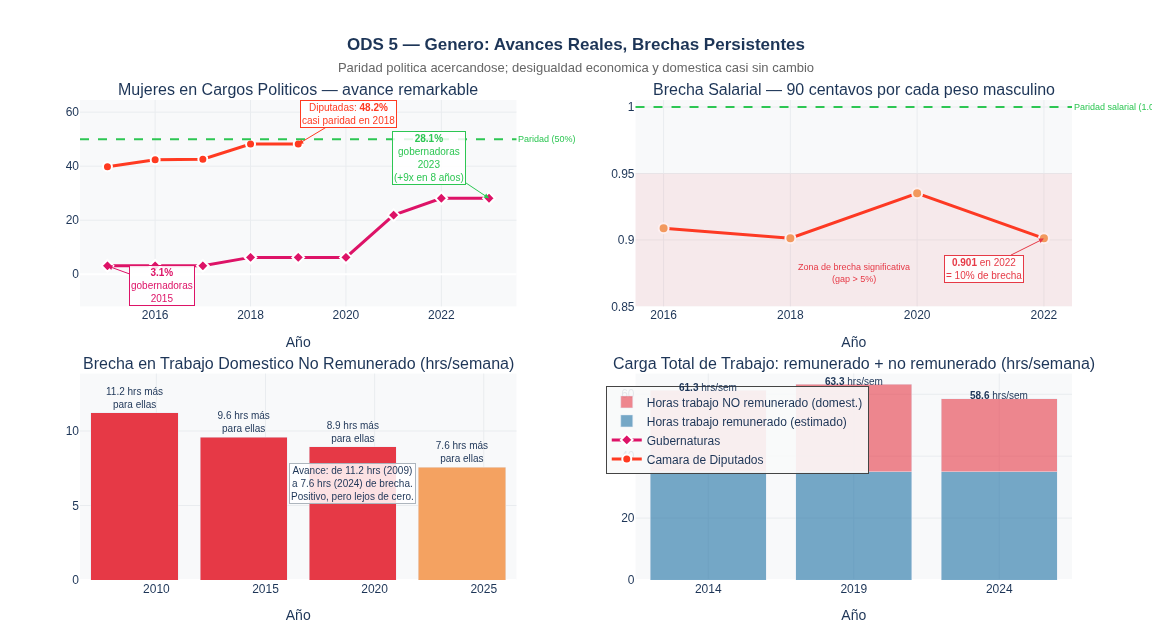

In [6]:
# ══════════════════════════════════════════════════════════════════════════════
# FIGURA 5 — Género: representacion política + brecha salarial + carga doméstica
# ══════════════════════════════════════════════════════════════════════════════

diputadas = get_serie('5.5.1.A')   # mujeres en Cámara de Diputados
gobernad  = get_serie('5.5.1.B')   # mujeres en gubernaturas
brecha_s  = get_serie('5N.1.1')    # razon ingreso laboral M/H
brecha_d  = get_serie('5N.1.2')    # brecha trabajo domestico H-M
carga_tot = get_serie('5R.4.1A')   # carga total de trabajo (remunerado + no rem.)
trab_dom  = get_serie('5.4.1A')    # trabajo domestico no remunerado

fig_gen = make_subplots(
    rows=2, cols=2,
    subplot_titles=[
        'Mujeres en Cargos Politicos — avance remarkable',
        'Brecha Salarial — 90 centavos por cada peso masculino',
        'Brecha en Trabajo Domestico No Remunerado (hrs/semana)',
        'Carga Total de Trabajo: remunerado + no remunerado (hrs/semana)'
    ],
    vertical_spacing=0.14, horizontal_spacing=0.12
)

# ── Panel 1: Representación política ─────────────────────────────────────────
fig_gen.add_trace(go.Scatter(
    x=diputadas['periodo'], y=diputadas['valor'],
    mode='lines+markers', name='Camara de Diputados',
    line=dict(color=C_ODS5, width=3),
    marker=dict(size=9, color=C_ODS5, line=dict(width=2, color='white')),
    hovertemplate='<b>%{x}</b><br>Diputadas: <b>%{y:.1f}%</b><extra></extra>'
), row=1, col=1)

fig_gen.add_trace(go.Scatter(
    x=gobernad['periodo'], y=gobernad['valor'],
    mode='lines+markers', name='Gubernaturas',
    line=dict(color=C_ODS10, width=3),
    marker=dict(size=9, color=C_ODS10, symbol='diamond',
                line=dict(width=2, color='white')),
    hovertemplate='<b>%{x}</b><br>Gobernadoras: <b>%{y:.1f}%</b><extra></extra>'
), row=1, col=1)

fig_gen.add_hline(
    y=50, line_dash='dash', line_color=C_MEJORA, line_width=2,
    row=1, col=1,
    annotation_text='Paridad (50%)',
    annotation_position='right',
    annotation_font=dict(size=9, color=C_MEJORA)
)

fig_gen.add_annotation(
    x=2015, y=3.1, text='<b>3.1%</b><br>gobernadoras<br>2015',
    showarrow=True, arrowhead=2, arrowcolor=C_ODS10,
    ax=55, ay=20, font=dict(size=10, color=C_ODS10),
    bgcolor='rgba(255,255,255,0.85)', bordercolor=C_ODS10, borderwidth=1,
    row=1, col=1
)
fig_gen.add_annotation(
    x=2023, y=28.1, text='<b>28.1%</b><br>gobernadoras<br>2023<br>(+9x en 8 años)',
    showarrow=True, arrowhead=2, arrowcolor=C_MEJORA,
    ax=-60, ay=-40, font=dict(size=10, color=C_MEJORA),
    bgcolor='rgba(255,255,255,0.85)', bordercolor=C_MEJORA, borderwidth=1,
    row=1, col=1
)
fig_gen.add_annotation(
    x=2019, y=48.2,
    text='Diputadas: <b>48.2%</b><br>casi paridad en 2018',
    showarrow=True, arrowhead=2, arrowcolor=C_ODS5,
    ax=50, ay=-30, font=dict(size=10, color=C_ODS5),
    bgcolor='rgba(255,255,255,0.85)', bordercolor=C_ODS5, borderwidth=1,
    row=1, col=1
)

# ── Panel 2: Brecha salarial ──────────────────────────────────────────────────
fig_gen.add_trace(go.Scatter(
    x=brecha_s['periodo'], y=brecha_s['valor'],
    mode='lines+markers',
    line=dict(color=C_ODS5, width=3),
    marker=dict(size=10, color=brecha_s['valor'].apply(
        lambda v: C_MEJORA if v >= 0.95 else C_ACENTO if v >= 0.90 else C_ALERTA
    ), line=dict(width=2, color='white')),
    showlegend=False,
    hovertemplate='<b>%{x}</b><br>Ingreso M/H: <b>%{y:.3f}</b> (1.0 = paridad)<extra></extra>'
), row=1, col=2)

fig_gen.add_hline(
    y=1.0, line_dash='dash', line_color=C_MEJORA, line_width=2,
    row=1, col=2,
    annotation_text='Paridad salarial (1.0)',
    annotation_position='right',
    annotation_font=dict(size=9, color=C_MEJORA)
)
fig_gen.add_hrect(
    y0=0.85, y1=0.95,
    fillcolor='rgba(230,57,70,0.08)', line_width=0,
    row=1, col=2
)
fig_gen.add_annotation(
    x=2019, y=0.875,
    text='Zona de brecha significativa<br>(gap > 5%)',
    showarrow=False, font=dict(size=9, color=C_ALERTA),
    row=1, col=2
)
fig_gen.add_annotation(
    x=2022, y=0.901,
    text='<b>0.901</b> en 2022<br>= 10% de brecha',
    showarrow=True, arrowhead=2, arrowcolor=C_ALERTA,
    ax=-60, ay=30, font=dict(size=10, color=C_ALERTA),
    bgcolor='rgba(255,255,255,0.85)', bordercolor=C_ALERTA, borderwidth=1,
    row=1, col=2
)

# ── Panel 3: Brecha trabajo doméstico ────────────────────────────────────────
fig_gen.add_trace(go.Bar(
    x=brecha_d['periodo'],
    y=brecha_d['valor'].abs(),  # valor negativo = mujeres hacen mas
    marker_color=[C_ALERTA if v < -8 else C_ACENTO if v < -7 else C_MEJORA
                  for v in brecha_d['valor']],
    text=['{:.1f} hrs más'.format(abs(v)) + '<br>para ellas' for v in brecha_d['valor']],
    textposition='outside', textfont=dict(size=10),
    showlegend=False,
    hovertemplate='<b>%{x}</b><br>Las mujeres hacen <b>%{y:.1f} hrs mas</b>/semana de trabajo domestico<extra></extra>'
), row=2, col=1)
fig_gen.add_annotation(
    x=2019, y=6.5,
    text='Avance: de 11.2 hrs (2009)<br>a 7.6 hrs (2024) de brecha.<br>Positivo, pero lejos de cero.',
    showarrow=False, font=dict(size=10, color=C_LINEA),
    bgcolor='rgba(255,255,255,0.85)', bordercolor='#ADB5BD', borderwidth=1,
    row=2, col=1
)

# ── Panel 4: Carga total de trabajo ──────────────────────────────────────────
carga_val = carga_tot['valor'].tolist()
carga_per = carga_tot['periodo'].tolist()

fig_gen.add_trace(go.Bar(
    name='Horas trabajo remunerado (estimado)',
    x=carga_per,
    y=[35, 35, 35],   # aprox trabajo remunerado
    marker_color='rgba(29,111,164,0.6)',
    showlegend=True
), row=2, col=2)

fig_gen.add_trace(go.Bar(
    name='Horas trabajo NO remunerado (domest.)',
    x=carga_per,
    y=[v - 35 for v in carga_val],
    marker_color='rgba(230,57,70,0.6)',
    showlegend=True,
    hovertemplate='<b>%{x}</b><br>No remunerado: <b>%{y:.1f} hrs</b>/semana<extra></extra>'
), row=2, col=2)

for periodo, total in zip(carga_per, carga_val):
    fig_gen.add_annotation(
        x=periodo, y=total + 1,
        text='<b>{:.1f}</b> hrs/sem'.format(total),
        showarrow=False, font=dict(size=10, color=C_LINEA),
        row=2, col=2
    )

fig_gen.update_layout(barmode='stack')
fig_gen.update_xaxes(showgrid=True, gridcolor='#E9ECEF', title_text='Año')
fig_gen.update_yaxes(showgrid=True, gridcolor='#E9ECEF')

fig_gen.update_layout(
    title=dict(
        text='<b>ODS 5 — Genero: Avances Reales, Brechas Persistentes</b><br>'
             '<span style="font-size:13px;color:#666;font-weight:normal">'
             'Paridad politica acercandose; desigualdad economica y domestica casi sin cambio</span>',
        x=0.5, xanchor='center'
    ),
    height=640, plot_bgcolor=C_FONDO, paper_bgcolor='white',
    font=dict(family='Inter, Arial, sans-serif', color=C_LINEA),
    legend=dict(x=0.53, y=0.22, bgcolor='rgba(248,249,250,0.9)', borderwidth=1),
    margin=dict(t=100, b=60)
)
fig_gen.show()

---
## Acto VI — La Discriminación: lo que los números casi no alcanzan a ver

El ODS 10.3.1 mide la proporción de la población que declara haber sufrido discriminación.  
Solo hay **dos puntos de datos**: 2017 y 2022.

Con apenas dos observaciones, no se puede hacer estadística. Pero el número sube: de **20.2%** a **23.7%** — casi 1 de cada 4 mexicanos declara haberse sentido discriminado.

Y el indicador 10N.3.1 muestra que el **33.8%** de las personas LGBTQ+ reportaron negación de derechos en 2022, bajando del 40.6% de 2017. Mejor — pero aún inaceptable.

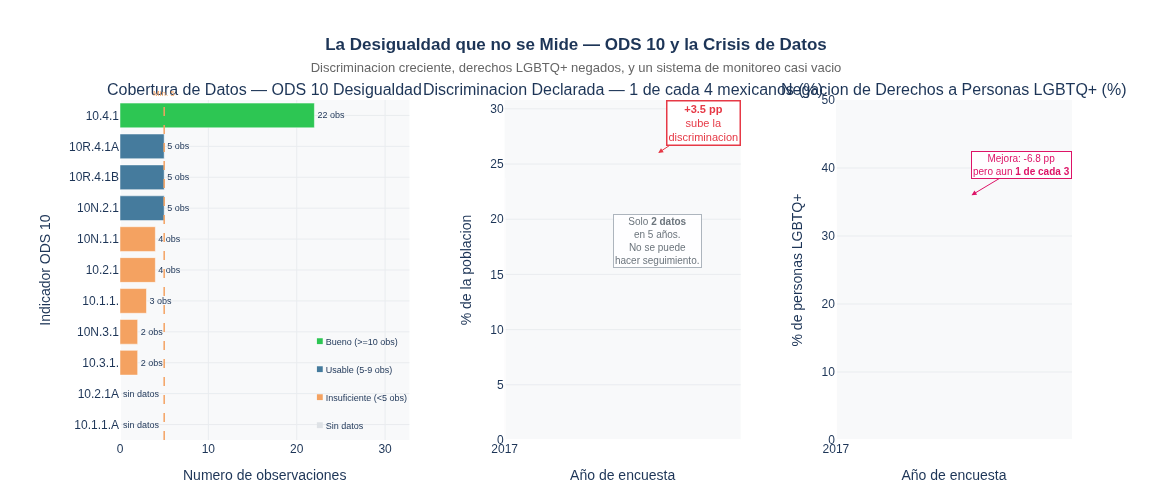

In [7]:
# ══════════════════════════════════════════════════════════════════════════════
# FIGURA 6 — Discriminación y derechos + el problema de datos
# ══════════════════════════════════════════════════════════════════════════════

disc  = get_serie('10.3.1.')    # discriminacion declarada
lgbtq = get_serie('10N.3.1')    # negacion derechos LGBTQ+

# ¿Cuántos indicadores ODS 10 tienen datos suficientes?
ods10_meta = meta[meta['ods_number']==10].copy()
ods10_meta['estado'] = ods10_meta.apply(
    lambda r: 'Sin datos' if not r['loaded'] or r['n_observations'] == 0
    else 'Insuficiente (<5 obs)' if r['n_observations'] < 5
    else 'Usable (5-9 obs)' if r['n_observations'] < 10
    else 'Bueno (>=10 obs)', axis=1
)

fig_disc = make_subplots(
    rows=1, cols=3,
    subplot_titles=[
        'Cobertura de Datos — ODS 10 Desigualdad',
        'Discriminacion Declarada — 1 de cada 4 mexicanos (%)',
        'Negacion de Derechos a Personas LGBTQ+ (%)'
    ],
    column_widths=[0.38, 0.31, 0.31],
    horizontal_spacing=0.1
)

# ── Panel 1: Mapa de cobertura ODS 10 ────────────────────────────────────────
color_estados = {
    'Sin datos':            '#DEE2E6',
    'Insuficiente (<5 obs)':'#F4A261',
    'Usable (5-9 obs)':     '#457B9D',
    'Bueno (>=10 obs)':     '#2DC653'
}

# Ordenar por numero de observaciones
ods10_meta_sort = ods10_meta.sort_values('n_observations', ascending=True)

fig_disc.add_trace(go.Bar(
    x=ods10_meta_sort['n_observations'],
    y=ods10_meta_sort['indicator_id'],
    orientation='h',
    marker_color=[color_estados[e] for e in ods10_meta_sort['estado']],
    marker_line_color='white', marker_line_width=0.5,
    text=['{} obs'.format(int(v)) if v > 0 else 'sin datos'
          for v in ods10_meta_sort['n_observations']],
    textposition='outside', textfont=dict(size=9),
    showlegend=False,
    hovertemplate='<b>%{y}</b><br>Observaciones: <b>%{x}</b><extra></extra>'
), row=1, col=1)

fig_disc.add_vline(
    x=5, line_dash='dash', line_color=C_ACENTO, line_width=1.5, row=1, col=1,
    annotation_text='Min. 5', annotation_position='top',
    annotation_font=dict(size=8, color=C_ACENTO)
)

# Leyenda manual como anotaciones
for i, (estado, color) in enumerate(color_estados.items()):
    fig_disc.add_annotation(
        x=22, y=i * 0.9,
        text='<span style="color:{};font-size:12px;">■</span> {}'.format(color, estado),
        showarrow=False, xanchor='left',
        font=dict(size=9, color=C_LINEA), row=1, col=1
    )

# ── Panel 2: Discriminación declarada ────────────────────────────────────────
fig_disc.add_trace(go.Bar(
    x=['2017', '2022'],
    y=disc['valor'].tolist(),
    marker_color=[C_ACENTO, C_ALERTA],
    marker_line_color='white', marker_line_width=1,
    text=['{:.1f}%'.format(v) for v in disc['valor']],
    textposition='outside', textfont=dict(size=14),
    showlegend=False,
    hovertemplate='<b>%{x}</b><br>Discriminacion declarada: <b>%{y:.1f}%</b><extra></extra>',
    width=0.4
), row=1, col=2)

fig_disc.add_annotation(
    x='2022', y=26,
    text='<b>+3.5 pp</b><br>sube la<br>discriminacion',
    showarrow=True, arrowhead=2, arrowcolor=C_ALERTA,
    ax=45, ay=-30, font=dict(size=11, color=C_ALERTA),
    bgcolor='rgba(255,255,255,0.9)', bordercolor=C_ALERTA, borderwidth=1.5,
    row=1, col=2
)
fig_disc.add_annotation(
    x='2019', y=18,
    text='Solo <b>2 datos</b><br>en 5 años.<br>No se puede<br>hacer seguimiento.',
    showarrow=False,
    font=dict(size=10, color=C_NEUTRO),
    bgcolor='rgba(255,255,255,0.85)', bordercolor='#ADB5BD', borderwidth=1,
    row=1, col=2
)

# ── Panel 3: LGBTQ+ ───────────────────────────────────────────────────────────
fig_disc.add_trace(go.Bar(
    x=['2017', '2022'],
    y=lgbtq['valor'].tolist(),
    marker_color=[C_ACENTO, C_ODS10],
    marker_line_color='white', marker_line_width=1,
    text=['{:.1f}%'.format(v) for v in lgbtq['valor']],
    textposition='outside', textfont=dict(size=14),
    showlegend=False,
    hovertemplate='<b>%{x}</b><br>Negacion derechos LGBTQ+: <b>%{y:.1f}%</b><extra></extra>',
    width=0.4
), row=1, col=3)

fig_disc.add_annotation(
    x='2022', y=36,
    text='Mejora: -6.8 pp<br>pero aun <b>1 de cada 3</b>',
    showarrow=True, arrowhead=2, arrowcolor=C_ODS10,
    ax=50, ay=-30, font=dict(size=10, color=C_ODS10),
    bgcolor='rgba(255,255,255,0.85)', bordercolor=C_ODS10, borderwidth=1,
    row=1, col=3
)

fig_disc.update_xaxes(showgrid=True, gridcolor='#E9ECEF')
fig_disc.update_yaxes(showgrid=True, gridcolor='#E9ECEF')
fig_disc.update_xaxes(title_text='Numero de observaciones', row=1, col=1)
fig_disc.update_xaxes(title_text='Año de encuesta', row=1, col=2)
fig_disc.update_xaxes(title_text='Año de encuesta', row=1, col=3)
fig_disc.update_yaxes(title_text='Indicador ODS 10', row=1, col=1)
fig_disc.update_yaxes(title_text='% de la poblacion', row=1, col=2)
fig_disc.update_yaxes(title_text='% de personas LGBTQ+', row=1, col=3, range=[0, 50])

fig_disc.update_layout(
    title=dict(
        text='<b>La Desigualdad que no se Mide — ODS 10 y la Crisis de Datos</b><br>'
             '<span style="font-size:13px;color:#666;font-weight:normal">'
             'Discriminacion creciente, derechos LGBTQ+ negados, y un sistema de monitoreo casi vacio</span>',
        x=0.5, xanchor='center'
    ),
    height=500, plot_bgcolor=C_FONDO, paper_bgcolor='white',
    font=dict(family='Inter, Arial, sans-serif', color=C_LINEA),
    margin=dict(t=100, b=60, l=120)
)
fig_disc.show()

---
## Acto VII — El Radar de la Desigualdad: dónde estamos en cada dimensión

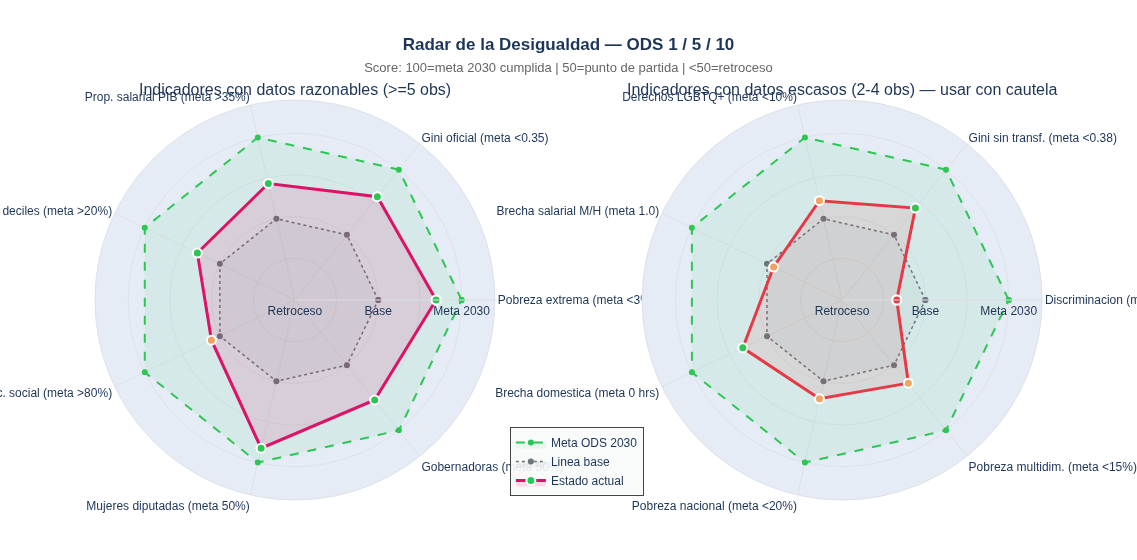


Scores (indicadores robustos):
  AVANZANDO  Pobreza extrema (meta <3%)          84.7/100
  AVANZANDO  Gini oficial (meta <0.35)           79.3/100
  AVANZANDO  Prop. salarial PIB (meta >35%)      71.7/100
  AVANZANDO  Ratio deciles (meta >20%)           65.0/100
  ESTANCADO  Cobertura protec. social (meta >80%)  55.6/100
  AVANZANDO  Mujeres diputadas (meta 50%)        91.2/100
  AVANZANDO  Gobernadoras (meta 50%)             76.7/100

Scores (indicadores con datos escasos — interpretar con cautela):
  RETROCESO  Discriminacion (meta <10%)          32.8/100
  AVANZANDO  Gini sin transf. (meta <0.38)       70.6/100
  ESTANCADO  Derechos LGBTQ+ (meta <10%)         61.1/100
  ESTANCADO  Brecha salarial M/H (meta 1.0)      45.6/100
  AVANZANDO  Brecha domestica (meta 0 hrs)       66.1/100
  ESTANCADO  Pobreza nacional (meta <20%)        60.8/100
  ESTANCADO  Pobreza multidim. (meta <15%)       63.8/100


In [8]:
# ══════════════════════════════════════════════════════════════════════════════
# FIGURA 7 — Radar de progreso: ODS 1 / 5 / 10 vs metas 2030
# Doble radar: dimensiones con datos robustos vs con datos escasos
# ══════════════════════════════════════════════════════════════════════════════

def norm_score(val, base, meta, mayor_mejor):
    """Normaliza a escala 0-100: 100=meta, 50=base, <50=retroceso"""
    if meta == base:
        return 50.0
    if mayor_mejor:
        return max(0, min(100, (val - base) / (meta - base) * 50 + 50))
    else:
        return max(0, min(100, (base - val) / (base - meta) * 50 + 50))

# Dimensiones medibles con datos razonables
dims_A = [
    # (etiqueta, base, actual, meta, mayor_mejor)
    ('Pobreza extrema\n(meta <3%)',              12.5, 5.9,   3.0,  False),
    ('Gini oficial\n(meta <0.35)',               0.449, 0.391, 0.350, False),
    ('Prop. salarial PIB\n(meta >35%)',          25.8, 29.8,  35.0,  True),
    ('Ratio deciles\n(meta >20%)',               9.3,  12.5,  20.0,  True),
    ('Cobertura protec.\nsocial (meta >80%)',    46.0, 49.8,  80.0,  True),
    ('Mujeres diputadas\n(meta 50%)',            39.8, 48.2,  50.0,  True),
    ('Gobernadoras\n(meta 50%)',                  3.1, 28.1,  50.0,  True),
]

# Dimensiones con datos escasos (advertencia)
dims_B = [
    ('Discriminacion\n(meta <10%)',              20.2, 23.7,  10.0,  False),
    ('Gini sin transf.\n(meta <0.38)',           0.499, 0.450, 0.380, False),
    ('Derechos LGBTQ+\n(meta <10%)',             40.6, 33.8,  10.0,  False),
    ('Brecha salarial\nM/H (meta 1.0)',          0.909, 0.901, 1.000, True),
    ('Brecha domestica\n(meta 0 hrs)',           11.2, 7.6,    0.0,  False),
    ('Pobreza nacional\n(meta <20%)',            50.0, 43.5,  20.0,  False),
    ('Pobreza multidim.\n(meta <15%)',           44.4, 36.3,  15.0,  False),
]

def calcular_scores(dims):
    cats   = [d[0] for d in dims]
    scores = [round(norm_score(d[2], d[1], d[3], d[4]), 1) for d in dims]
    cats_c   = cats + [cats[0]]
    scores_c = scores + [scores[0]]
    return cats, scores, cats_c, scores_c

cats_A, scores_A, cats_Ac, scores_Ac = calcular_scores(dims_A)
cats_B, scores_B, cats_Bc, scores_Bc = calcular_scores(dims_B)

fig_radar = make_subplots(
    rows=1, cols=2,
    subplot_titles=[
        'Indicadores con datos razonables (>=5 obs)',
        'Indicadores con datos escasos (2-4 obs) — usar con cautela'
    ],
    specs=[[{'type':'polar'}, {'type':'polar'}]],
    horizontal_spacing=0.12
)

polar_base_A = dict(radialaxis=dict(
    visible=True, range=[0,120],
    tickvals=[0,25,50,75,100],
    ticktext=['Retroceso','','Base','','Meta\n2030'],
    gridcolor='#DEE2E6', linecolor='#DEE2E6'
), angularaxis=dict(linecolor='#DEE2E6', gridcolor='#DEE2E6'))

for col, cats, cats_c, scores_c, note_color in [
    (1, cats_A, cats_Ac, scores_Ac, C_ODS10),
    (2, cats_B, cats_Bc, scores_Bc, C_ALERTA)
]:
    # Meta
    fig_radar.add_trace(go.Scatterpolar(
        r=[100]*len(cats)+[100], theta=cats+[cats[0]],
        fill='toself', fillcolor='rgba(44,198,83,0.08)',
        line=dict(color=C_MEJORA, width=2, dash='dash'),
        name='Meta ODS 2030', showlegend=(col==1)
    ), row=1, col=col)
    # Base
    fig_radar.add_trace(go.Scatterpolar(
        r=[50]*len(cats)+[50], theta=cats+[cats[0]],
        fill='toself', fillcolor='rgba(108,117,125,0.06)',
        line=dict(color=C_NEUTRO, width=1.5, dash='dot'),
        name='Linea base', showlegend=(col==1)
    ), row=1, col=col)
    # Actual
    pt_colors = [
        C_ALERTA if s < 40 else C_ACENTO if s < 65 else C_MEJORA
        for s in scores_c[:-1]
    ]
    fig_radar.add_trace(go.Scatterpolar(
        r=scores_c, theta=cats_c,
        fill='toself',
        fillcolor='rgba(221,19,103,0.12)' if col==1 else 'rgba(230,57,70,0.10)',
        line=dict(color=note_color, width=3),
        mode='lines+markers',
        marker=dict(size=9, color=pt_colors+[pt_colors[0]],
                    line=dict(width=2, color='white')),
        name='Estado actual', showlegend=(col==1),
        hovertemplate='<b>%{theta}</b><br>Score: <b>%{r:.0f}/100</b><extra></extra>'
    ), row=1, col=col)

if col == 1:
    fig_radar.update_layout(polar=polar_base_A)
fig_radar.update_layout(
    polar=polar_base_A,
    polar2=polar_base_A,
)

fig_radar.update_layout(
    title=dict(
        text='<b>Radar de la Desigualdad — ODS 1 / 5 / 10</b><br>'
             '<span style="font-size:13px;color:#666;font-weight:normal">'
             'Score: 100=meta 2030 cumplida | 50=punto de partida | <50=retroceso</span>',
        x=0.5, xanchor='center'
    ),
    height=560, paper_bgcolor='white',
    font=dict(family='Inter, Arial, sans-serif', color=C_LINEA),
    legend=dict(x=0.44, y=0.01, bgcolor='rgba(248,249,250,0.9)', borderwidth=1),
    margin=dict(t=100, b=60)
)
fig_radar.show()

print('\nScores (indicadores robustos):')
for cat, score in zip(cats_A, scores_A):
    s = 'RETROCESO' if score < 40 else 'ESTANCADO' if score < 65 else 'AVANZANDO'
    print('  {:<10s} {:<34s} {:5.1f}/100'.format(s, cat.replace('\n',' '), score))

print('\nScores (indicadores con datos escasos — interpretar con cautela):')
for cat, score in zip(cats_B, scores_B):
    s = 'RETROCESO' if score < 40 else 'ESTANCADO' if score < 65 else 'AVANZANDO'
    print('  {:<10s} {:<34s} {:5.1f}/100'.format(s, cat.replace('\n',' '), score))

---
## Conclusiones — El Diagnóstico de la Desigualdad

### Lo que los datos revelan — y lo que no pueden revelar

---

**1. El problema de fondo es epistemológico: medimos mal lo que más importa.**  
ODS 5 (Género) tiene un promedio de 3.6 observaciones por indicador — estadísticamente inservible. ODS 10 (Desigualdad) tiene 5.8, con la mitad de los indicadores sin datos usables. No podemos combatir la desigualdad sin saber dónde está.

**2. El Gini mejora, pero la desigualdad estructural persiste.**  
La brecha de 0.06 entre el Gini con y sin transferencias revela que el Estado está compensando —no corrigiendo— la desigualdad. Cuando las transferencias se interrumpen, la desigualdad real reaparece.

**3. El 70% del PIB no va a los trabajadores.**  
Solo el 29.8% del PIB llega en forma de salarios. Un modelo productivo donde el capital captura 70 centavos de cada peso generado no puede producir reducción estructural de la desigualdad.

**4. Casi la mitad del país sigue en pobreza nacional.**  
43.5% es una cifra que debería dominar el debate público. No lo hace. El éxito relativo en pobreza extrema internacional eclipsa la pobreza multidimensional, que afecta al 36.3% de la población.

**5. La discriminación sube; los derechos LGBTQ+ mejoran lentamente.**  
Con apenas 2 datos cada indicador, no podemos rastrear tendencias. Lo que vemos apunta en direcciones opuestas: discriminación al alza, derechos LGBTQ+ mejorando — pero el sistema no puede saberlo con certeza.

**6. El avance en género es real en lo político, inacabado en lo económico.**  
De 3% a 28% de gobernadoras en 8 años es un logro histórico. Pero una brecha salarial del 10% con casi cero movimiento en 6 años, y 7.6 horas semanales extra de trabajo doméstico no remunerado sobre las mujeres, muestran que la igualdad formal no se ha traducido en igualdad material.

---

### ¿Qué necesita México para reducir la desigualdad de verdad?

| Prioridad | Acción concreta |
|-----------|----------------|
| **Urgente** | Fortalecer el sistema estadístico: ENIGH y ENUT cada 2 años, no cada 4-5 |
| **Estructural** | Aumentar la proporción salarial del PIB — salario mínimo, negociación colectiva |
| **Fiscal** | Reforma tributaria progresiva: reducir la dependencia de transferencias como sustituto de igualdad |
| **Social** | Universalizar la seguridad social: el 50% sin acceso es la mayor fuente de desigualdad |
| **De datos** | Crear el Registro de Discriminación: medir con frecuencia anual, no quinquenal |
| **De género** | Infraestructura de cuidados: guarderías, permisos paternales, para cerrar la brecha doméstica |

---

> **El mensaje central:** La desigualdad que no se mide es la desigualdad que no se combate.  
> México necesita invertir tanto en el sistema de medición como en las políticas de fondo.

---

*Análisis basado en indicadores ODS 1, 5 y 10 de México · INEGI/CONEVAL 2026 · HackODS 2026*  
*Método: análisis descriptivo, normalización por metas ODS 2030, cobertura estadística*